In [1]:
import pandas as pd

from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY
from src.exploringtools.InitBackbone import InitBackbone
from src.exploringtools.InitClassifier import InitClassifier, ztf_order_classes
from src.exploringtools.InitDataloader import InitDataLoader


from src.exploringtools.InitCombinator import InitCombinator
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier

from src.layers.classifiers.HierClassifiery import Hier
from src.layers.transformer.ATAT import TabularTransformer, LightCurveTransformer
import numpy as np

import pandas as pd

from sklearn.metrics import classification_report

In [2]:

FP_DATASET = "/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5"

DEVICE = 'cuda:0'
DATASET = 'test'
reports_1 = []
reports_2 = []
RANGE = 1

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/exploringtools/InitBackbone.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serializati

True False False
Using checkpoint 25758.ckpt
Using checkpoint 25758.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


100%|██████████| 1188/1188 [00:22<00:00, 53.77it/s]


               precision    recall  f1-score   support

         CART     0.8630    0.2520    0.3901      1000
        SNIax     0.6468    0.3370    0.4431      1000
         91bg     0.8184    0.6220    0.7068      1000
         SNIa     0.5378    0.7900    0.6399      1000
        SNIbc     0.4247    0.5640    0.4845      1000
         SNII     0.3941    0.7110    0.5071      1000
         SLSN     0.7717    0.8520    0.8099      1000
         PISN     0.8271    0.9520    0.8852      1000
          TDE     0.8904    0.9020    0.8962      1000
         ILOT     0.9392    0.6640    0.7780      1000
           KN     0.9672    0.8560    0.9082      1000
M-dwarf Flare     0.9661    0.9130    0.9388      1000
    Microlens     0.9179    0.9500    0.9337      1000
  Dwarf Novae     0.9718    0.9290    0.9499      1000
          AGN     0.9920    0.9910    0.9915      1000
   DeltaScuti     0.9827    0.9670    0.9748      1000
          RRL     0.9752    0.9850    0.9801      1000
      Cep

<Axes: title={'center': 'Lightcurve Classification | Dataset: test | macro f1: 0.7996'}, xlabel='Predicted label', ylabel='True label'>

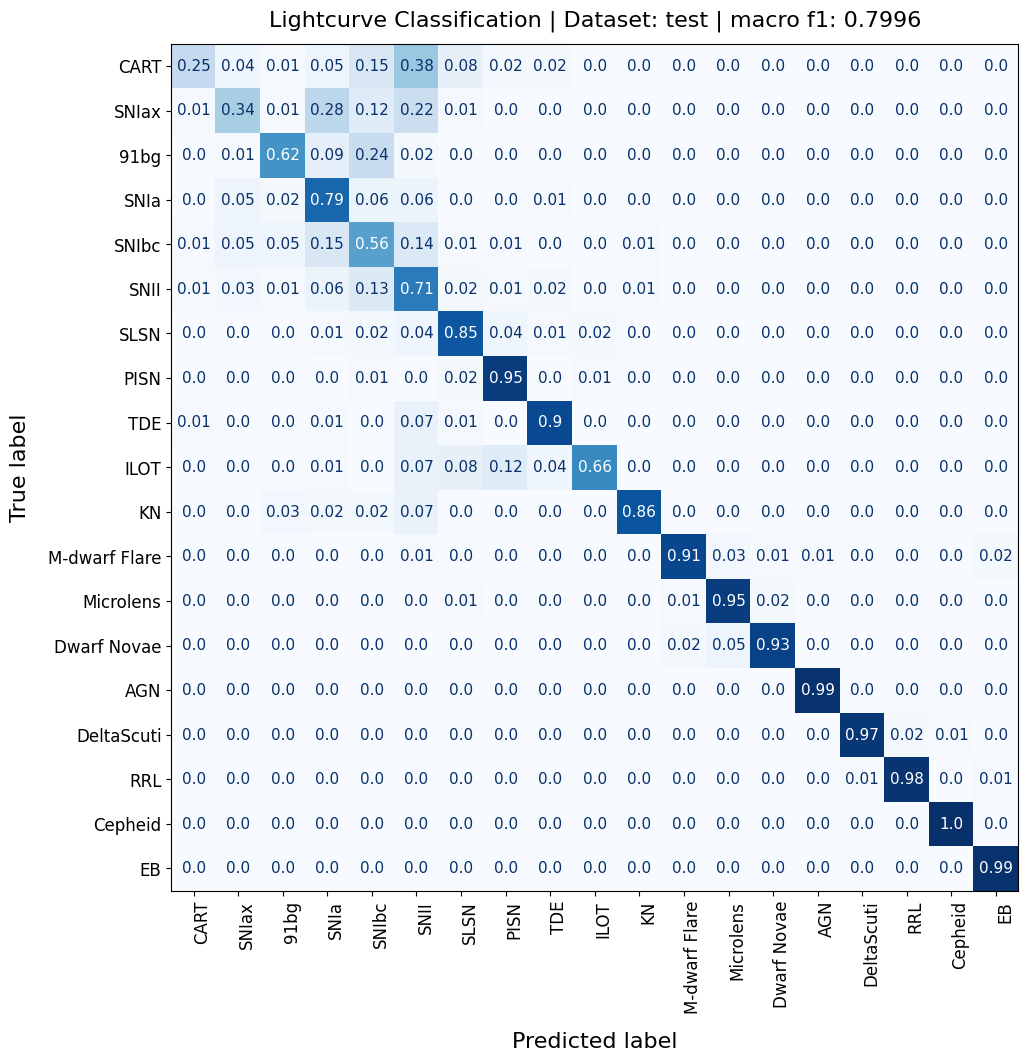

In [4]:
test = InitClassifier(path_to_config_yaml="/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/OLD_ELASTICC/LC/class_og_dataset_1/",
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)
test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()


import numpy as np
from sklearn.metrics import classification_report
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_1 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ELASTICC_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ELASTICC_TAXONOMY().keys()),digits = 4, output_dict=False))
#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ELASTICC_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)
test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ELASTICC_TAXONOMY, plot_title= 'Lightcurve Classification | Dataset', order_classes=list(ELASTICC_TAXONOMY().keys()))

In [5]:
#model.eval().to(device = 'cuda:0')
import torch
from copy import deepcopy
from tqdm import tqdm
time2eval = [8,16,32,64,128,256,512,1024,2048]
evaluated_times = {}


target = None
preds_out = None
       # print(self.atat)
test.backbone.eval().to(device=DEVICE)
test.classifier.eval().to(device=DEVICE)
for eval_t in time2eval:
  print(f'=== eval_t {eval_t} ===')
  print('  ')
  target = None
  preds_out = None
  for b1 in tqdm(dl.test_dataset):
      mask_time = (b1['time'] < eval_t).float()
      b1['mask'] = (b1['mask'] * mask_time).bool()
      b1['time'] = b1['time'] * b1['mask']
      b1['data'] =b1['data'] * b1['mask']
      b1 = {key: value.to(device=DEVICE) for key, value in b1.items()}
      t = b1["labels"]
      emb = test.backbone(**b1)
      emb = test.classifier(emb)
      if isinstance(emb, dict):
          if 'LC' in emb.keys():
              output = emb["LC"]
          if 'TAB' in emb.keys():
              output = emb["TAB"]
          if 'MIX' in emb.keys():
              output = emb["MIX"]

      preds_out = (
          np.concatenate([preds_out, output.detach().cpu().numpy()])
          if preds_out is not None
          else output.cpu().detach().numpy()
      )
      target = (
          np.concatenate([target, t.cpu().detach().numpy()])
          if target is not None
          else t.detach().cpu().numpy()
          )

  #val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
  #print(val_preds)
  #print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ELASTICC_TAXONOMY().keys()),digits = 4, output_dict=False))
  evaluated_times.update({f'{eval_t}':classification_report(target,np.argmax(preds_out, axis = -1), target_names=list(ELASTICC_TAXONOMY().keys()),digits = 4,output_dict =True)})
# break  #print(classification)


=== eval_t 8 ===
  


  0%|          | 0/1188 [00:00<?, ?it/s]

100%|██████████| 1188/1188 [00:21<00:00, 55.58it/s]
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control t

=== eval_t 16 ===
  


100%|██████████| 1188/1188 [00:21<00:00, 54.37it/s]


...

100%|██████████| 1188/1188 [00:21<00:00, 54.68it/s]


=== eval_t 1024 ===
  


100%|██████████| 1188/1188 [00:21<00:00, 54.04it/s]


=== eval_t 2048 ===
  


100%|██████████| 1188/1188 [00:21<00:00, 54.31it/s]


In [6]:
for key, value in evaluated_times.items():
  print(key,value['macro avg']['f1-score'])

8 0.06683345075045166
16 0.11003121000306357
32 0.16626699400404768
64 0.29755375680688606
128 0.45429510032985204
256 0.5134893785375627
512 0.6231593628817486
1024 0.7472431015253655
2048 0.750217707187344


In [11]:

RANGE = 5
report_1 = []
for i in range(RANGE):
  test = InitClassifier(path_to_config_yaml=f"/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/FF/LC/class_five_fold_windows_{i}/",
                      model= LightCurveTransformer,
                      classifier = MultimodalClassifier,
                      use_lc = True,
                      arg_key='lc')

  backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
  classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
  test.load_backbone_weights(backbone_od)

  test.load_classifier_weights(classifier_od)
  test.args.datamodule.val_use_sampler = False

  dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
  dl.init_test_dataset()
  import numpy as np

  from sklearn.metrics import classification_report
  val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
  report_1.append(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ELASTICC_TAXONOMY().keys()),digits = 4, output_dict=True))
  print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ELASTICC_TAXONOMY().keys()),digits = 4, output_dict=False))
  #test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ELASTICC_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)
  #test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ELASTICC_TAXONOMY, plot_title= 'Lightcurve Classification | Dataset', order_classes=list(ELASTICC_TAXONOMY().keys()))


print(report_1)

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/exploringtools/InitBackbone.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serializati

True False False
Using checkpoint 7440.ckpt
Using checkpoint 7440.ckpt


RuntimeError: Error(s) in loading state_dict for LightCurveTransformer:
	Missing key(s) in state_dict: "transformer_lc.norm.weight", "transformer_lc.norm.bias". 

In [ ]:

np.mean([r['macro avg']['f1-score'] for r in report_1]), np.std([r['macro avg']['f1-score'] for r in report_1])

In [ ]:
from pprint import pprint
pprint(evaluated_times['8'])

In [ ]:
test = InitCombinator(path_to_config_yaml=PATH,
                    lc_model= LightCurveTransformer,
                    tab_model= TabularTransformer,
                    classifier = MultimodalClassifier,
                    classifier_args={'use_lc':False,
                                     'use_tab':False,
                                     'use_mix':True},
                    arg_key='tab',
                    device = DEVICE)

print(test.atat)

False False True
Found checkpoint 33867.ckpt


/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/exploringtools/InitCombinator.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serializa

Found checkpoint 33867.ckpt
Loaded backbone weights
Loaded backbone weights
Found checkpoint 33867.ckpt
Loaded backbone weights
/home/mdelafuente/ORIGINAL/metadata/fold_0.joblib


/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.2.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/mo

device set to cuda:0


100%|██████████| 594/594 [00:15<00:00, 39.05it/s]


               precision    recall  f1-score   support

         CART     0.8688    0.6290    0.7297      1000
        SNIax     0.7488    0.6440    0.6925      1000
         91bg     0.9157    0.9010    0.9083      1000
         SNIa     0.7258    0.8630    0.7885      1000
        SNIbc     0.6063    0.7100    0.6541      1000
         SNII     0.6465    0.7150    0.6790      1000
         SLSN     0.9294    0.9480    0.9386      1000
         PISN     0.9292    0.9840    0.9558      1000
          TDE     0.9022    0.9410    0.9212      1000
         ILOT     0.9515    0.8430    0.8940      1000
           KN     0.9813    0.9440    0.9623      1000
M-dwarf Flare     0.9806    0.9100    0.9440      1000
    Microlens     0.9237    0.9680    0.9453      1000
  Dwarf Novae     0.9479    0.9470    0.9475      1000
          AGN     0.9990    0.9980    0.9985      1000
   DeltaScuti     0.9880    0.9920    0.9900      1000
          RRL     0.9940    0.9860    0.9900      1000
      Cep

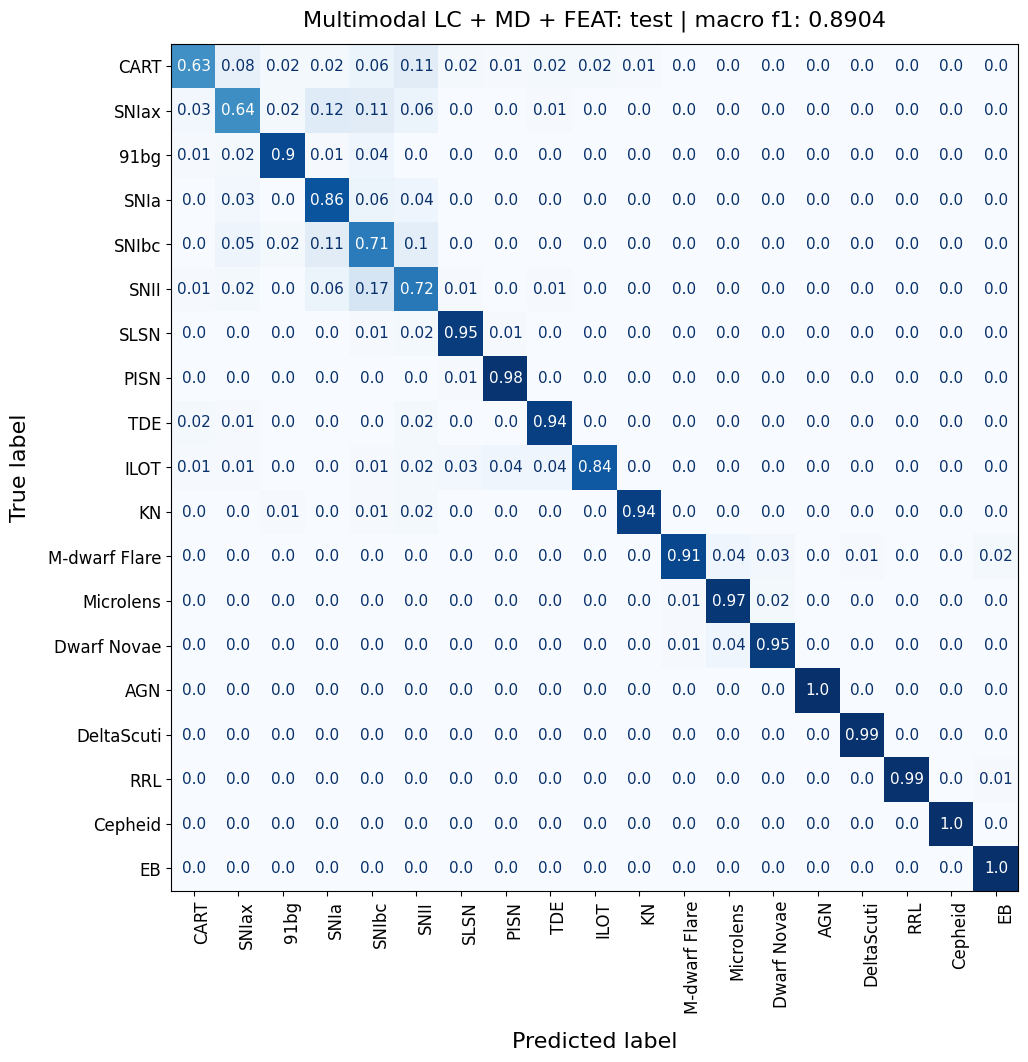

In [3]:
RANGE =1
for i in range(RANGE):
    PATH = f'/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/OLD_ELASTICC/LC_MD_FEAT/class_og_dataset_v2_{i}/'

    test = InitCombinator(path_to_config_yaml=PATH,
                    lc_model= LightCurveTransformer,
                    tab_model= TabularTransformer,
                    classifier = MultimodalClassifier,
                    classifier_args={'use_lc':False,
                                     'use_tab':False,
                                     'use_mix':True},
                    arg_key='tab',
                    device = DEVICE)
    dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=32,datamodule_args=test.args.datamodule)
    dl.init_test_dataset() if DATASET == 'test' else dl.init_validation_dataset()

    val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)

    print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ELASTICC_TAXONOMY().keys()),digits = 4, output_dict=False))
    test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ELASTICC_TAXONOMY, plot_title= 'Multimodal LC + MD + FEAT', order_classes=list(ELASTICC_TAXONOMY().keys()))
    reports_1.append(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ELASTICC_TAXONOMY().keys()),digits = 4, output_dict=True))
print("##################")

In [6]:
import pandas as pd

metrics = pd.read_csv('/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/OLD_ELASTICC/LC/class_og_dataset_0/metrics/metrics.csv')

<Axes: >

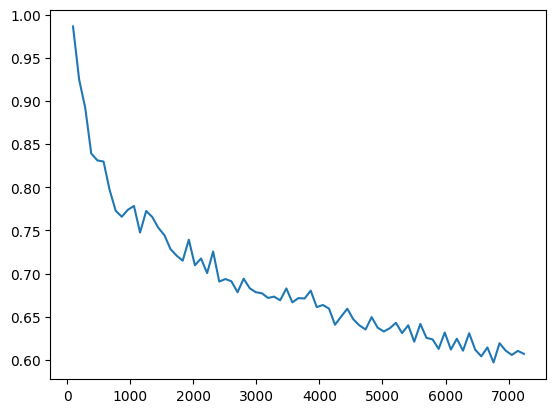

In [7]:
metrics['loss_validation/lc'].dropna().plot()

<Axes: >

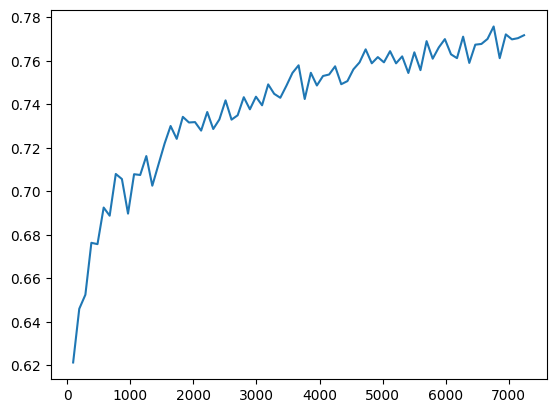

In [8]:
metrics['validation/LC/f1_macro'].dropna().plot()

In [ ]:
asdfadsf

In [ ]:

def summarize_classification_reports(reports):
    """
    Given a list of sklearn classification_report dictionaries (with output_dict=True),
    compute the mean and standard deviation across them and return a formatted string report.
    """
    # Convert each report to a DataFrame and collect them
    df_list = [pd.DataFrame(r).transpose() for r in reports]

    # Align all DataFrames, using outer join to include all possible labels
    all_labels = sorted(set().union(*[df.index for df in df_list]))
    df_list = [df.reindex(all_labels) for df in df_list]

    # Combine and group by label
    combined = pd.concat(df_list).groupby(level=0)

    # Compute mean and std
    mean_df = combined.mean()
    std_df = combined.std()

    # Format the output string
    report_str = ""
    metrics = ['precision', 'recall', 'f1-score']

    for label in mean_df.index:
        if label == 'accuracy':
            # Accuracy is a single float, stored in the "precision" column
            acc_mean = mean_df.loc[label].get('precision', float('nan'))
            acc_std = std_df.loc[label].get('precision', float('nan'))
            report_str += f"{label:>12}  {acc_mean:.4f}$\\pm${acc_std:.4f}&\n"
        else:
            values = []
            for metric in metrics:
                mean_val = mean_df.loc[label].get(metric, float('nan'))
                std_val = std_df.loc[label].get(metric, float('nan'))
                values.append(f"{mean_val:.4f}$\\pm${std_val:.4f} &")
            support = mean_df.loc[label].get('support', float('nan'))
            report_str += f"{label:>12}  & " + "  ".join(values) + f"  {int(support):>5}" +'\\\ ' + '\n'
        top = [
        r'\begin{table}[ht]',
        r'\centering',
        r'\small',
        r'\begin{tabular}{lcccc}',
        r'\toprule',
        '{} {} '.format(4*' & ',r'\\'),
        r'\midrule'
        '\n'
    ]
    bottom= [
        r'\bottomrule',

        r'\end{tabular}',

        r'\caption{Classification Report}',
        r'\label{tab:classification_report}',
        r'\end{table}'
    ]
    return '\n'.join(top) +  report_str+ '\n'.join(bottom)


In [9]:
embeddings, target =test.predict(dl.test_dataset, DEVICE, pred_type='embeddings') if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)

device set to cuda:0


  0%|          | 0/1188 [00:00<?, ?it/s]

 34%|███▍      | 407/1188 [01:03<02:01,  6.43it/s]


KeyboardInterrupt: 

In [ ]:
from sklearn.discriminant_analysis import StandardScaler
import umap
import umap.plot
scaler = StandardScaler()
#bokeh.io.output_notebook(INLINE)
umap_args = {'min_dist':0.1}
umap_obj = umap.UMAP(**umap_args)
#mapper = umap_obj.fit(scaler.fit_transform(X_val))
mapper = umap_obj.fit(embeddings)
hover_data = pd.DataFrame({'index':range(len(embeddings)),
                            'label':target,
                            })

hover_data['class'] = hover_data.label.map({value:key for key,value in ELASTICC_TAXONOMY().items()})

In [ ]:
umap.plot.output_notebook()
p = umap.plot.interactive(mapper,
    labels=target,
    hover_data=hover_data,
    point_size=2,
    tools=["pan","wheel_zoom",
    "box_zoom","save",
    "reset","box_select"],
    width=1920,
    height=1080,
    #theme = 'fire',
    #color_key = colors_hier,
    #color_key = colors,
    background = 'black', #midnightblue',
    alpha = 0.9)
umap.plot.show(p)

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (21,13))
ax = fig.add_subplot(111)
plt.title('UMAP Dimensionality Reduction for the Pretrained Embedding Space by Hierarchy Class')
umap.plot.points(mapper, labels = np.array([{value:key for key, value in ELASTICC_TAXONOMY().items()}[i] for i in target.astype(int)]), height = 1080, width = 1920, background = 'black', ax = ax, alpha = 0.7,

)


In [ ]:
RANGE = 1
for i in range(RANGE):
    #PATH = f'/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ELASTICC/LC_MD_FEAT/MM_class_ELASTICC_all_data_5e4_ogtransforms_{i}/'
    PATH = f'/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ELASTICC/LC_MD_FEAT/MM_class_ELASTICC_AUGMENTATIONS_{i}/'

    #PATH = f'/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/64_128/LC_MD_FEAT/MM_class_64_128_{i}/'
    test = InitCombinator(path_to_config_yaml=PATH,
                    lc_model= LightCurveTransformer,
                    tab_model= TabularTransformer,
                    classifier = MultimodalClassifier,
                    classifier_args={'use_lc':False,
                                     'use_tab':False,
                                     'use_mix':True},
                    arg_key='tab',
                    device = DEVICE)

    dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=32,datamodule_args=test.args.datamodule)
    dl.init_test_dataset()
    val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
    #print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ELASTICC_TAXONOMY().keys()),digits = 4, output_dict=False))
    #test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)
    reports_2.append(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ELASTICC_TAXONOMY().keys()),digits = 4, output_dict=True))

def summarize_classification_reports(reports):
    """
    Given a list of sklearn classification_report dictionaries (with output_dict=True),
    compute the mean and standard deviation across them and return a formatted string report.
    """
    # Convert each report to a DataFrame and collect them
    df_list = [pd.DataFrame(r).transpose() for r in reports]

    # Align all DataFrames, using outer join to include all possible labels
    all_labels = sorted(set().union(*[df.index for df in df_list]))
    df_list = [df.reindex(all_labels) for df in df_list]

    # Combine and group by label
    combined = pd.concat(df_list).groupby(level=0)

    # Compute mean and std
    mean_df = combined.mean()
    std_df = combined.std()

    # Format the output string
    report_str = ""
    metrics = ['precision', 'recall', 'f1-score']

    for label in mean_df.index:
        if label == 'accuracy':
            # Accuracy is a single float, stored in the "precision" column
            acc_mean = mean_df.loc[label].get('precision', float('nan'))
            acc_std = std_df.loc[label].get('precision', float('nan'))
            report_str += f"{label:>12}  {acc_mean:.4f}$\\pm${acc_std:.4f}&\n"
        else:
            values = []
            for metric in metrics:
                mean_val = mean_df.loc[label].get(metric, float('nan'))
                std_val = std_df.loc[label].get(metric, float('nan'))
                values.append(f"{mean_val:.4f}$\\pm${std_val:.4f} &")
            support = mean_df.loc[label].get('support', float('nan'))
            report_str += f"{label:>12}  & " + "  ".join(values) + f"  {int(support):>5}" +'\\\ ' + '\n'
        top = [
        r'\begin{table}[ht]',
        r'\centering',
        r'\small',
        r'\begin{tabular}{lcccc}',
        r'\toprule',
        '{} {} '.format(4*' & ',r'\\'),
        r'\midrule'
        '\n'
    ]
    bottom= [
        r'\bottomrule',
        r'\end{tabular}',
        r'\caption{Classification Report}',
        r'\label{tab:classification_report}',
        r'\end{table}'
    ]
    return '\n'.join(top) +  report_str+ '\n'.join(bottom)


##########



<>:60: SyntaxWarning: invalid escape sequence '\ '
<>:60: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_3321716/820347227.py:60: SyntaxWarning: invalid escape sequence '\ '
  report_str += f"{label:>12}  & " + "  ".join(values) + f"  {int(support):>5}" +'\\\ ' + '\n'
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/exploringtools/InitCombinator.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future re

False False True
Found checkpoint 9540.ckpt
Found checkpoint 9540.ckpt


/tmp/ipykernel_3321716/820347227.py:60: SyntaxWarning: invalid escape sequence '\ '
  report_str += f"{label:>12}  & " + "  ".join(values) + f"  {int(support):>5}" +'\\\ ' + '\n'


RuntimeError: Error(s) in loading state_dict for LightCurveTransformer:
	Missing key(s) in state_dict: "transformer_lc.norm.weight", "transformer_lc.norm.bias". 

In [ ]:
np.mean([reports_2[0]['macro avg']['f1-score'],
        reports_2[1]['macro avg']['f1-score'],
        reports_2[2]['macro avg']['f1-score']])

In [ ]:
mean_df= pd.concat([pd.DataFrame(reports_2[0]).drop('support').T,
           pd.DataFrame(reports_2[1]).drop('support').T,
           pd.DataFrame(reports_2[2]).drop('support').T]).reset_index().groupby('index').aggregate(lambda x: np.mean(list(x)))

In [ ]:
std_df =pd.concat([pd.DataFrame(reports_2[0]).drop('support').T,
           pd.DataFrame(reports_2[1]).drop('support').T,
           pd.DataFrame(reports_2[2]).drop('support').T]).reset_index().groupby('index').aggregate(lambda x: np.std(list(x)))

In [ ]:
from pprint import pprint
#pprint(reports_1[0])
import pandas as pd
metrics =[]

for rep in reports_2:


  metrics.append(pd.DataFrame(rep))

mean_stats_2 = pd.concat(metrics).reset_index().rename(columns = {'index':'metric'}).groupby('metric').describe()#.sort_values('level_1')#columns#.query('level_1 == std')
mean_stats_2 = mean_stats_2.T.reset_index().query('level_1 == "mean"')

for rep in reports_2:

  metrics.append(pd.DataFrame(rep))

std_stats_2 = pd.concat(metrics).reset_index().rename(columns = {'index':'metric'}).groupby('metric').describe()#.sort_values('level_1')#columns#.query('level_1 == std')
std_stats_2 = std_stats_2.T.reset_index().query('level_1 == "std"')


display(mean_stats_2)
display(std_stats_2)


In [ ]:
mean_collected = mean_stats_1.merge(mean_stats_2, on = ['level_0','level_1','support'],suffixes = ['_baseline','_pretrained'], how = 'left').drop(columns = 'level_1')
mean_collected = mean_collected[['level_0', 'precision_baseline', 'recall_baseline', 'f1-score_baseline',
        'precision_pretrained',
       'recall_pretrained','f1-score_pretrained', 'support']]
mean_collected['support'] =mean_collected['support'].astype(int)
mean_collected = mean_collected.round(4).rename(columns = {'level_0':'class'})#.drop(columns = 'metric')

In [ ]:
from pprint import pprint
#pprint(reports_1[0])
import pandas as pd
metrics =[]

for rep in reports_1:

  metrics.append(pd.DataFrame(rep))


std_stats_1 = pd.concat(metrics).reset_index().rename(columns = {'index':'metric'}).groupby('metric').describe()#.sort_values('level_1')#columns#.query('level_1 == std')
std_stats_1 = std_stats_1.T.reset_index().query('level_1 == "std"')


In [ ]:
std_collected = std_stats_1.merge(std_stats_2, on = ['level_0','level_1','support'],suffixes = ['_baseline','_pretrained'], how = 'left').drop(columns = 'level_1')
std_collected = std_collected[['level_0', 'precision_baseline', 'recall_baseline', 'f1-score_baseline',
        'precision_pretrained',
       'recall_pretrained','f1-score_pretrained', 'support']]
std_collected['support'] =std_collected['support'].astype(int)
std_collected = std_collected.round(4).rename(columns = {'level_0':'class'})#.drop(columns = 'metric')

In [ ]:
COLS = ['precision_baseline','recall_baseline','f1-score_baseline','precision_pretrained','recall_pretrained','f1-score_pretrained']
formated = pd.concat([mean_collected['class'],"&"+mean_collected[COLS].astype(str) + "\pm" + std_collected[COLS].astype(str),"&" + mean_collected['support'].astype(str) + f'\ \\'], axis = 1)

In [ ]:
formated = pd.concat([mean_collected['class'],mean_collected[COLS].astype(str) + "\pm" + std_collected[COLS].astype(str),mean_collected['support'].astype(str)], axis = 1)
print(formated.to_latex())